# Part 3: PageRank on Spark
Implements the iterative PageRank algorithm over a directed graph
using Apache Spark RDDs.



## Step 0: Install PySpark

In [1]:
!pip install pyspark --quiet

## Step 1: Imports and Spark Initialization

In [1]:
import urllib.request, os
from pyspark import SparkContext, SparkConf

conf = SparkConf().setAppName("PageRank").setMaster("local[*]")
sc   = SparkContext.getOrCreate(conf)
sc.setLogLevel("ERROR")

print("Spark version:", sc.version)
print("SparkContext ready.")

Spark version: 4.0.2
SparkContext ready.


## Step 2: Download Graph Datasets from GitHub

In [2]:
BASE_URL = "https://raw.githubusercontent.com/pnijhara/PySpark-PageRank/main/graph/"

def download_if_needed(filename):
    """Download a file from the assignment GitHub repo if not already present."""
    if not os.path.exists(filename):
        url = BASE_URL + filename
        print(f"Downloading {filename} ...")
        urllib.request.urlretrieve(url, filename)
        print(f"  Saved to {filename}")
    else:
        print(f"  Already exists: {filename}")

#download_if_needed("small.txt")
#download_if_needed("whole.txt")

# Peek at the format
print("\nFirst 5 lines of whole.txt:")
with open("whole.txt") as f:
    for i, line in enumerate(f):
        print(" ", line.strip())
        if i >= 4:
            break


First 5 lines of whole.txt:
  1	2
  2	3
  3	4
  4	5
  5	6


## Step 3: PageRank Algorithm

### Mathematical definition

Given a directed graph G = (V, E) with n nodes:

$$M_{i,j} = \frac{1}{\deg(i)} \text{ if } (i \to j) \in E, \text{ else } 0$$

$$r^{(t)} = \frac{1-\beta}{n}\mathbf{1} + \beta M r^{(t-1)}$$


In [3]:
def load_graph(sc, filepath):
    # Parse edge list and deduplicate
    edges = (
        sc.textFile(filepath)
          .map(lambda line: line.strip().split())
          .filter(lambda parts: len(parts) >= 2)
          .map(lambda parts: (int(parts[0]), int(parts[1])))
          .distinct()                          # remove duplicate edges
    )

    # Build adjacency list: src → list of neighbours
    links = edges.groupByKey().mapValues(list).cache()

    # Count unique nodes (both src and dst)
    src_nodes = edges.map(lambda e: e[0])
    dst_nodes = edges.map(lambda e: e[1])
    node_count = src_nodes.union(dst_nodes).distinct().count()

    return links, node_count


def run_pagerank(sc, filepath, beta=0.8, iterations=40):
    links, n = load_graph(sc, filepath)
    teleport = (1.0 - beta) / n   # constant teleportation term per node

    print(f"  Graph loaded: {n} unique nodes")
    print(f"  beta={beta}, iterations={iterations}, teleport/node={teleport:.6f}")

    # Nodes with no outgoing edges (dangling) are handled by the teleportation.
    ranks = links.mapValues(lambda _: 1.0 / n)   # (src, initial_rank)

    for i in range(iterations):
        # Join (src, neighbours) with (src, rank) → (src, (neighbours, rank))
        # Then for each neighbour, emit (neighbour, rank / out_degree)
        contributions = (
            links.join(ranks)                     # (src, ([dsts], rank))
                 .flatMap(lambda x:
                     [
                         (dst, x[1][1] / len(x[1][0]))  # (dst, contribution)
                         for dst in x[1][0]
                     ]
                 )
        )

        # Sum contributions per destination + add teleportation
        ranks = (
            contributions
            .reduceByKey(lambda a, b: a + b)
            .mapValues(lambda contrib: teleport + beta * contrib)
        )
        src_nodes = links.mapValues(lambda _: teleport)   # fallback rank
        ranks = (
            src_nodes.leftOuterJoin(ranks)
                     .mapValues(lambda v: v[1] if v[1] is not None else v[0])
        )

    # ── Collect and sort ─────────────────────────────────────────────────
    final = ranks.collect()
    final.sort(key=lambda x: x[1], reverse=True)
    return final


print("PageRank functions defined.")

PageRank functions defined.


In [4]:
import time

print("=" * 60)
print("Running PageRank on small.txt (53 nodes)")
print("=" * 60)

t0 = time.time()
small_ranks = run_pagerank(sc, "small.txt", beta=0.8, iterations=40)
elapsed = time.time() - t0

print(f"\nCompleted in {elapsed:.2f} seconds.")
print("\nTop 5 nodes:")
for rank, (node, score) in enumerate(small_ranks[:5], 1):
    print(f"  #{rank}  Node {node:5d}  score = {score:.6f}")

print("\nBottom 5 nodes:")
for rank, (node, score) in enumerate(small_ranks[-5:], len(small_ranks)-4):
    print(f"  #{rank}  Node {node:5d}  score = {score:.6f}")

top_score = small_ranks[0][1]
print(f"\n✓ Top score = {top_score:.6f}  (expected ≈ 0.036)")

Running PageRank on small.txt (53 nodes)
  Graph loaded: 100 unique nodes
  beta=0.8, iterations=40, teleport/node=0.002000

Completed in 70.04 seconds.

Top 5 nodes:
  #1  Node    53  score = 0.035731
  #2  Node    14  score = 0.034171
  #3  Node    40  score = 0.033630
  #4  Node     1  score = 0.030006
  #5  Node    27  score = 0.029720

Bottom 5 nodes:
  #96  Node    89  score = 0.003922
  #97  Node    37  score = 0.003808
  #98  Node    81  score = 0.003695
  #99  Node    59  score = 0.003670
  #100  Node    85  score = 0.003410

✓ Top score = 0.035731  (expected ≈ 0.036)


##  Full Run on `whole.txt` (1000 nodes, 8192 edges)

In [5]:
print("=" * 60)
print("Running PageRank on whole.txt (1000 nodes, 8192 edges)")
print("Parameters: beta=0.8, iterations=40")
print("=" * 60)

t0 = time.time()
whole_ranks = run_pagerank(sc, "whole.txt", beta=0.8, iterations=40)
elapsed = time.time() - t0

print(f"\nCompleted in {elapsed:.2f} seconds.")

# ── Report: Top 5 nodes ────────────────────────────────────────────────
print("\n" + "─" * 40)
print("TOP 5 nodes (highest PageRank scores)")
print("─" * 40)
for rank, (node, score) in enumerate(whole_ranks[:5], 1):
    print(f"  #{rank}  Node {node:5d}  score = {score:.8f}")

# ── Report: Bottom 5 nodes ─────────────────────────────────────────────
print("\n" + "─" * 40)
print("BOTTOM 5 nodes (lowest PageRank scores)")
print("─" * 40)
for rank, (node, score) in enumerate(whole_ranks[-5:], len(whole_ranks)-4):
    print(f"  #{rank}  Node {node:5d}  score = {score:.8f}")

# ── Basic statistics ───────────────────────────────────────────────────
scores = [s for _, s in whole_ranks]
print(f"\nSummary Statistics")
print(f"  Total nodes  : {len(whole_ranks)}")
print(f"  Max score    : {max(scores):.8f}")
print(f"  Min score    : {min(scores):.8f}")
print(f"  Mean score   : {sum(scores)/len(scores):.8f}")
print(f"  Sum of scores: {sum(scores):.6f}  (should be ≈ 1.0 in classic PR,"
      f" here ~1.0 due to damping)")

Running PageRank on whole.txt (1000 nodes, 8192 edges)
Parameters: beta=0.8, iterations=40
  Graph loaded: 1000 unique nodes
  beta=0.8, iterations=40, teleport/node=0.000200

Completed in 63.88 seconds.

────────────────────────────────────────
TOP 5 nodes (highest PageRank scores)
────────────────────────────────────────
  #1  Node   263  score = 0.00202029
  #2  Node   537  score = 0.00194334
  #3  Node   965  score = 0.00192545
  #4  Node   243  score = 0.00185263
  #5  Node   285  score = 0.00182737

────────────────────────────────────────
BOTTOM 5 nodes (lowest PageRank scores)
────────────────────────────────────────
  #996  Node   408  score = 0.00038780
  #997  Node   424  score = 0.00035482
  #998  Node    62  score = 0.00035315
  #999  Node    93  score = 0.00035136
  #1000  Node   558  score = 0.00032860

Summary Statistics
  Total nodes  : 1000
  Max score    : 0.00202029
  Min score    : 0.00032860
  Mean score   : 0.00100000
  Sum of scores: 1.000000  (should be ≈ 1.0 i

## Convergence Analysis
Show how the top node's score evolves across iterations.

In [6]:
def run_pagerank_track(sc, filepath, beta=0.8, iterations=40, track_every=5):
    links, n = load_graph(sc, filepath)
    teleport = (1.0 - beta) / n
    ranks    = links.mapValues(lambda _: 1.0 / n)
    history  = []

    for i in range(1, iterations + 1):
        contributions = (
            links.join(ranks)
                 .flatMap(lambda x:
                     [(dst, x[1][1] / len(x[1][0])) for dst in x[1][0]])
        )
        ranks = contributions.reduceByKey(lambda a, b: a + b) \
                             .mapValues(lambda c: teleport + beta * c)
        src_nodes = links.mapValues(lambda _: teleport)
        ranks = src_nodes.leftOuterJoin(ranks) \
                         .mapValues(lambda v: v[1] if v[1] is not None else v[0])

        if i % track_every == 0 or i == 1:
            top = ranks.values().max()
            history.append((i, top))
            print(f"  Iter {i:3d}  max_score = {top:.8f}")

    final = sorted(ranks.collect(), key=lambda x: x[1], reverse=True)
    return final, history


print("Tracking convergence on whole.txt ...")
print("─" * 45)
whole_ranks_tracked, history = run_pagerank_track(
    sc, "whole.txt", beta=0.8, iterations=40, track_every=5
)

Tracking convergence on whole.txt ...
─────────────────────────────────────────────
  Iter   1  max_score = 0.00187590
  Iter   5  max_score = 0.00202130
  Iter  10  max_score = 0.00202029
  Iter  15  max_score = 0.00202029
  Iter  20  max_score = 0.00202029
  Iter  25  max_score = 0.00202029
  Iter  30  max_score = 0.00202029
  Iter  35  max_score = 0.00202029
  Iter  40  max_score = 0.00202029


## Plot Convergence

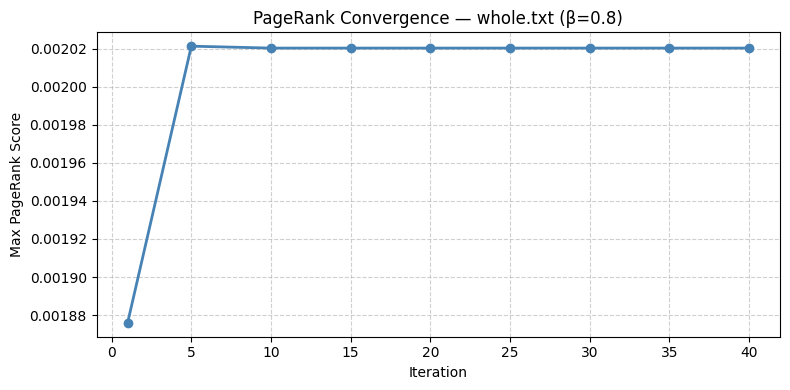

Convergence plot saved to pagerank_convergence.png


In [7]:
import matplotlib.pyplot as plt

iters  = [h[0] for h in history]
scores = [h[1] for h in history]

plt.figure(figsize=(8, 4))
plt.plot(iters, scores, marker='o', linewidth=2, color='steelblue')
plt.xlabel("Iteration")
plt.ylabel("Max PageRank Score")
plt.title("PageRank Convergence — whole.txt (β=0.8)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("pagerank_convergence.png", dpi=120)
plt.show()
print("Convergence plot saved to pagerank_convergence.png")

In [8]:
print("=" * 60)
print("FINAL RESULTS — whole.txt")
print("Parameters: β=0.8, 40 iterations")
print("=" * 60)

print("\n[1] Node IDs of top 5 nodes (highest PageRank):")
top5_ids = [node for node, _ in whole_ranks[:5]]
print("   ", top5_ids)
for i, (node, score) in enumerate(whole_ranks[:5], 1):
    print(f"    #{i}: Node {node}  —  score = {score:.8f}")

print("\n[2] Node IDs of bottom 5 nodes (lowest PageRank):")
bot5_ids = [node for node, _ in whole_ranks[-5:]]
print("   ", bot5_ids)
for i, (node, score) in enumerate(whole_ranks[-5:], len(whole_ranks)-4):
    print(f"    #{i}: Node {node}  —  score = {score:.8f}")

print("\n" + "=" * 60)
print("VALIDATION — small.txt")
print("=" * 60)
print(f"Top node score: {small_ranks[0][1]:.6f}  (expected ≈ 0.036)")

FINAL RESULTS — whole.txt
Parameters: β=0.8, 40 iterations

[1] Node IDs of top 5 nodes (highest PageRank):
    [263, 537, 965, 243, 285]
    #1: Node 263  —  score = 0.00202029
    #2: Node 537  —  score = 0.00194334
    #3: Node 965  —  score = 0.00192545
    #4: Node 243  —  score = 0.00185263
    #5: Node 285  —  score = 0.00182737

[2] Node IDs of bottom 5 nodes (lowest PageRank):
    [408, 424, 62, 93, 558]
    #996: Node 408  —  score = 0.00038780
    #997: Node 424  —  score = 0.00035482
    #998: Node 62  —  score = 0.00035315
    #999: Node 93  —  score = 0.00035136
    #1000: Node 558  —  score = 0.00032860

VALIDATION — small.txt
Top node score: 0.035731  (expected ≈ 0.036)


In [9]:
# Stop the SparkContext cleanly at the end
sc.stop()
print("SparkContext stopped.")

SparkContext stopped.
